In [ ]:
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt
import tensorflow as tf
#from tensorflow.keras import layers

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
x_path = '/content/drive/My Drive/Assignment 2 - handwriting/x_letters.npy'
y_path = '/content/drive/My Drive/Assignment 2 - handwriting/y_letters.npy'

X = np.load(x_path)
y = np.load(y_path)

X = X.astype("float32")
if X.max() > 1.0:
    X /= 255.0
if X.ndim == 3:
    X = np.expand_dims(X, axis=-1)
y = y.astype("int32")

num_classes = int(np.max(y)) + 1
image_shape = X.shape[1:]

In [139]:
valid_size = min(5000, max(1, X.shape[0] // 10))
X_train, X_valid = X[:-valid_size], X[-valid_size:]
y_train, y_valid = y[:-valid_size], y[-valid_size:]

In [140]:
batch_size = 64
train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
            .batch(batch_size, drop_remainder=True)
            .prefetch(tf.data.AUTOTUNE))

valid_ds = (tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))


In [141]:
LATENT_DIM = 128

def build_genreator(image_shape, num_classes, latent_dim=LATENT_DIM):
    H, W, C = image_shape
    z_in = layers.Input(shape=(latent_dim,), name="z")
    lbl_in = layers.Input(shape=(1,), dtype="int32", name="class_id")
    emb = layers.Embedding(num_classes, 50)(lbl_in)
    emb = layers.Flatten()(emb)
    x = layers.Concatenate()([z_in, emb])
    x = layers.Dense(7*7*256, use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Reshape((7, 7, 256))(x)
    x = layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    out = layers.Conv2D(C, 3, padding="same", activation="sigmoid")(x)
    return keras.Model([z_in, lbl_in], out, name="generator")

def build_discriminator(image_shape, num_classes):
    img_in = layers.Input(shape=image_shape, name="image")
    lbl_in = layers.Input(shape=(1,), dtype="int32", name="class_id")
    H, W, C = image_shape
    emb = layers.Embedding(num_classes, H*W)(lbl_in)
    lbl_img = layers.Reshape((H, W, 1))(emb)
    x = layers.Concatenate()([img_in, lbl_img])
    def Conv(f,k,s): return layers.Conv2D(f, k, strides=s, padding="same")
    x = Conv(64,3,2)(x); x = layers.LeakyReLU(0.2)(x)
    x = Conv(128,3,2)(x); x = layers.LeakyReLU(0.2)(x)
    x = Conv(256,3,2)(x); x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128)(x); x = layers.LeakyReLU(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model([img_in, lbl_in], out, name="discriminator")

generator = build_genreator(image_shape, num_classes, LATENT_DIM)
discriminator = build_discriminator(image_shape, num_classes)

generator.summary()
discriminator.summary()


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ class_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │      1,300 │ class_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (InputLayer)      │ (None, 128)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 178)       │          0 │ z[0][0],          │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 12544)     │  2,232,832 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 12544)     │     50,176 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 12544)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 7, 7, 256) │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 14, 14,    │    524,288 │ reshape[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 28, 28,    │    131,072 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28, 1) │        577 │ re_lu_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,941,013 (11.22 MB)

 Trainable params: 2,915,541 (11.12 MB)

 Non-trainable params: 25,472 (99.50 KB)

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ class_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 784)    │     20,384 │ class_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 28, 28, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 28, 28, 1) │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 28, 28, 2) │          0 │ image[0][0],      │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      1,216 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 14, 14,    │          0 │ conv2d_1[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 7, 7, 128) │          0 │ conv2d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 4, 4, 256) │    295,168 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 4, 4, 256) │          0 │ conv2d_3[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4096)      │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │    524,416 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ leaky_re_lu_3[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 915,169 (3.49 MB)

 Trainable params: 915,169 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [142]:
class cGAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def call(self, inputs, training=None):
        real_images, class_labels = inputs
        batch_size = tf.shape(class_labels)[0]
        z = tf.random.normal((batch_size, self.latent_dim), dtype=real_images.dtype)
        fake = self.generator([z, class_labels], training=training)
        return self.discriminator([fake, class_labels], training=training)

    def train_step(self, data):
        real_images, class_labels = data
        batch = tf.shape(real_images)[0]

        z = tf.random.normal((batch, self.latent_dim), dtype=real_images.dtype)
        fake = self.generator([z, class_labels], training=True)
        combined_images = tf.concat([fake, real_images], axis=0)
        combined_labels = tf.concat([class_labels, class_labels], axis=0)

        targets = tf.concat([tf.zeros((batch,1)), tf.ones((batch,1))], axis=0)
        targets += 0.05 * tf.random.uniform(tf.shape(targets))

        with tf.GradientTape() as tape:
            preds = self.discriminator([combined_images, combined_labels], training=True)
            d_loss = self.loss_fn(targets, preds)
        d_grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

        z = tf.random.normal((batch, self.latent_dim), dtype=real_images.dtype)
        misleading = tf.ones((batch,1))
        with tf.GradientTape() as tape:
            gen_imgs = self.generator([z, class_labels], training=True)
            preds = self.discriminator([gen_imgs, class_labels], training=True)
            g_loss = self.loss_fn(misleading, preds)
        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}

    def test_step(self, data):

        real_images, class_labels = data
        batch = tf.shape(real_images)[0]

        # D loss
        z = tf.random.normal((batch, self.latent_dim), dtype=real_images.dtype)
        fake = self.generator([z, class_labels], training=False)
        combined_images = tf.concat([fake, real_images], axis=0)
        combined_labels = tf.concat([class_labels, class_labels], axis=0)
        targets = tf.concat([tf.zeros((batch,1)), tf.ones((batch,1))], axis=0)
        preds = self.discriminator([combined_images, combined_labels], training=False)
        d_loss = self.loss_fn(targets, preds)

        # G loss
        z = tf.random.normal((batch, self.latent_dim), dtype=real_images.dtype)
        gen_imgs = self.generator([z, class_labels], training=False)
        preds = self.discriminator([gen_imgs, class_labels], training=False)
        g_loss = self.loss_fn(tf.ones((batch,1)), preds)

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        return {"d_loss": self.d_loss_metric.result(), "g_loss": self.g_loss_metric.result()}


In [143]:
cgan = cGAN(generator, discriminator, LATENT_DIM)
cgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

In [144]:

epochs = 25

history = cgan.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=epochs
)


Epoch 1/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - d_loss: 0.5634 - g_loss: 1.0423 - val_d_loss: 0.6586 - val_g_loss: 0.5887
Epoch 2/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6348 - g_loss: 0.7940 - val_d_loss: 0.6333 - val_g_loss: 0.6796
Epoch 3/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6328 - g_loss: 0.7989 - val_d_loss: 0.6496 - val_g_loss: 0.9126
Epoch 4/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6261 - g_loss: 0.8211 - val_d_loss: 0.6347 - val_g_loss: 1.0516
Epoch 5/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6267 - g_loss: 0.8189 - val_d_loss: 0.6242 - val_g_loss: 0.8667
Epoch 6/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6297 - g_loss: 0.8117 - val_d_loss: 0.6430 - val_g_loss: 1.0679
Epoch 7/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6315 - g_loss: 0.8058 - val_d_loss: 0.6416 - val_g_loss: 0.6782
Epoch 8/25
1309/1309 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - d_loss: 0.6320 - g_loss: 0.8134 -

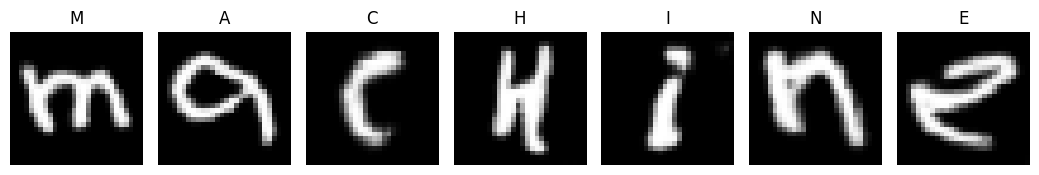

In [145]:
def plot_word(generator, text, latent_dim, base):
    letters = [c for c in text.lower() if 'a' <= c <= 'z']
    labels = tf.constant([[ord(c) - 97 + base] for c in letters], tf.int32)
    z = tf.random.normal((len(letters), latent_dim))

    imgs = generator([z, labels], training=False).numpy()
    H, W, C = imgs.shape[1:]
    imgs = imgs[..., 0] if C == 1 else imgs

    plt.figure(figsize=(len(letters)*1.5, 2))
    for i, ch in enumerate(letters):
        plt.subplot(1, len(letters), i + 1)
        plt.imshow(imgs[i], cmap="gray" if C == 1 else None)
        plt.title(ch.upper())
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_word(generator, "machine", LATENT_DIM, 0)